# 전처리 5단계 — DWI (기상위험지수) 계산

## DWI란?

> 기온·습도·실효습도·풍속을 하나의 숫자로 합친 '기상 위험 점수'입니다.  
> 최종 산불위험지수(P-FFDRI)에서 기상 파트 55%를 담당합니다.

## 계산 순서

```
1단계  PreDWI  = sigmoid(2.706 + 0.088×기온 - 0.055×습도 - 0.023×실효습도 - 0.104×풍속)
                → 0~1 연속값  (건조·고온일수록 1에 가까움)

2단계  등급화  = PreDWI를 1~10 등급으로 재분류 (산림청 봄철 기준)

3단계  DWI    = 등급 × RNE  (RNE: 최근 3일 강수 감쇠 효과)
                → 0.1~10 범위  (높을수록 위험)
```

## 사용한 파생변수
| 변수 | 출처 | 역할 |
|------|------|------|
| ta_mean | weather_scaled | 일평균기온 |
| hm_mean | weather_scaled | 일평균상대습도 |
| wind_ws_mean | weather_scaled | 일평균풍속 |
| effective_humidity | derived/effective_humidity | 실효습도 (과거 4일 가중) |
| rne | derived/rne | 강우효과 |

> **출처**: 산림청 FFDRI 알고리즘 설명서 (2026.04.20)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, time, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_PATH   = r'D:\prj_2_공모전\data\003. 전처리 데이터(preprocessing_data)'
SCALED_PATH = os.path.join(BASE_PATH, 'weather_scaled')
EH_PATH     = os.path.join(BASE_PATH, 'derived', 'effective_humidity')
RNE_PATH    = os.path.join(BASE_PATH, 'derived', 'rne')
DWI_PATH    = os.path.join(BASE_PATH, 'derived', 'dwi')
WD_PATH     = os.path.join(BASE_PATH, 'derived', 'w_d.parquet')
MONTHS      = ['2025-02','2025-03','2025-04','2025-05']

# 봄철 재분류 기준 (산림청 FFDRI 고정값)
SPRING_BINS   = [0.0, 0.1183, 0.1878, 0.2571, 0.3320,
                 0.4089, 0.4932, 0.5861, 0.6862, 0.7820, 1.001]
SPRING_LABELS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

print('설정 완료')

설정 완료


---
## Step 1. 계산 함수 정의

In [2]:
def predwi_spring(ta, hm, eh, ws):
    """봄철(1~6월) PreDWI 계산. 입력값은 모두 ÷10 스케일 적용된 실제 단위."""
    x = 2.706 + 0.088*ta - 0.055*hm - 0.023*eh - 0.104*ws
    return (1.0 / (1.0 + np.exp(-x))).astype('float32')

def reclassify(predwi):
    return pd.cut(predwi, bins=SPRING_BINS,
                  labels=SPRING_LABELS, include_lowest=True).astype('int8')

# 시나리오 검증
scenarios = [
    ('극건조 고온',  27.0, 15.0, 12.0, 8.0),
    ('4월 평균적',   15.0, 50.0, 48.0, 2.0),
    ('2월 평균적',    0.0, 60.0, 50.0, 2.0),
    ('비 직후',       8.0, 90.0, 85.0, 2.0),
]
print(f'{"시나리오":<14} {"PreDWI":>8} {"등급":>5}  해석')
print('-' * 50)
for name, ta, hm, eh, ws in scenarios:
    p = float(predwi_spring(np.array([ta]), np.array([hm]),
                             np.array([eh]), np.array([ws]))[0])
    cls = int(pd.cut([p], bins=SPRING_BINS, labels=SPRING_LABELS, include_lowest=True)[0])
    note = '위험' if cls >= 8 else '보통' if cls >= 5 else '안전'
    print(f'{name:<14} {p:>8.4f} {cls:>5}  [{note}]')

시나리오             PreDWI    등급  해석
--------------------------------------------------
극건조 고온           0.9589    10  [위험]
4월 평균적           0.4910     6  [보통]
2월 평균적           0.1243     2  [안전]
비 직후             0.0241     1  [안전]


---
## Step 2. 전체 DWI 계산 (월별)

In [3]:
os.makedirs(DWI_PATH, exist_ok=True)
start = time.time()

for m in MONTHS:
    t0 = time.time()
    print(f'[{m}] 계산 중...', end=' ', flush=True)

    df_w  = pd.read_parquet(SCALED_PATH, filters=[('month','==',m)],
                             columns=['grid_id','date','ta_mean','hm_mean','wind_ws_mean'])
    df_eh = pd.read_parquet(EH_PATH,  filters=[('month','==',m)])
    df_rn = pd.read_parquet(RNE_PATH, filters=[('month','==',m)],
                             columns=['grid_id','date','rne'])

    df = df_w.merge(df_eh[['grid_id','date','effective_humidity']], on=['grid_id','date'])
    df = df.merge(df_rn, on=['grid_id','date'])

    df['predwi']       = predwi_spring(df['ta_mean'].values, df['hm_mean'].values,
                                        df['effective_humidity'].values, df['wind_ws_mean'].values)
    df['predwi_class'] = reclassify(df['predwi'])
    df['dwi']          = (df['predwi_class'].astype('float32') * df['rne']).astype('float32')

    out_dir = os.path.join(DWI_PATH, f'month={m}')
    os.makedirs(out_dir, exist_ok=True)
    df[['grid_id','date','predwi','predwi_class','dwi']].to_parquet(
        os.path.join(out_dir, 'data.parquet'), index=False, engine='pyarrow', compression='snappy')

    print(f'완료 ({time.time()-t0:.1f}초)  avg DWI={df["dwi"].mean():.2f}')

print(f'\n전체: {time.time()-start:.1f}초')

[2025-02] 계산 중... 완료 (13.6초)  avg DWI=2.66
[2025-03] 계산 중... 완료 (17.2초)  avg DWI=3.00
[2025-04] 계산 중... 완료 (16.3초)  avg DWI=4.11
[2025-05] 계산 중... 완료 (17.3초)  avg DWI=2.81

전체: 64.5초


---
## Step 3. 검증 및 시각화

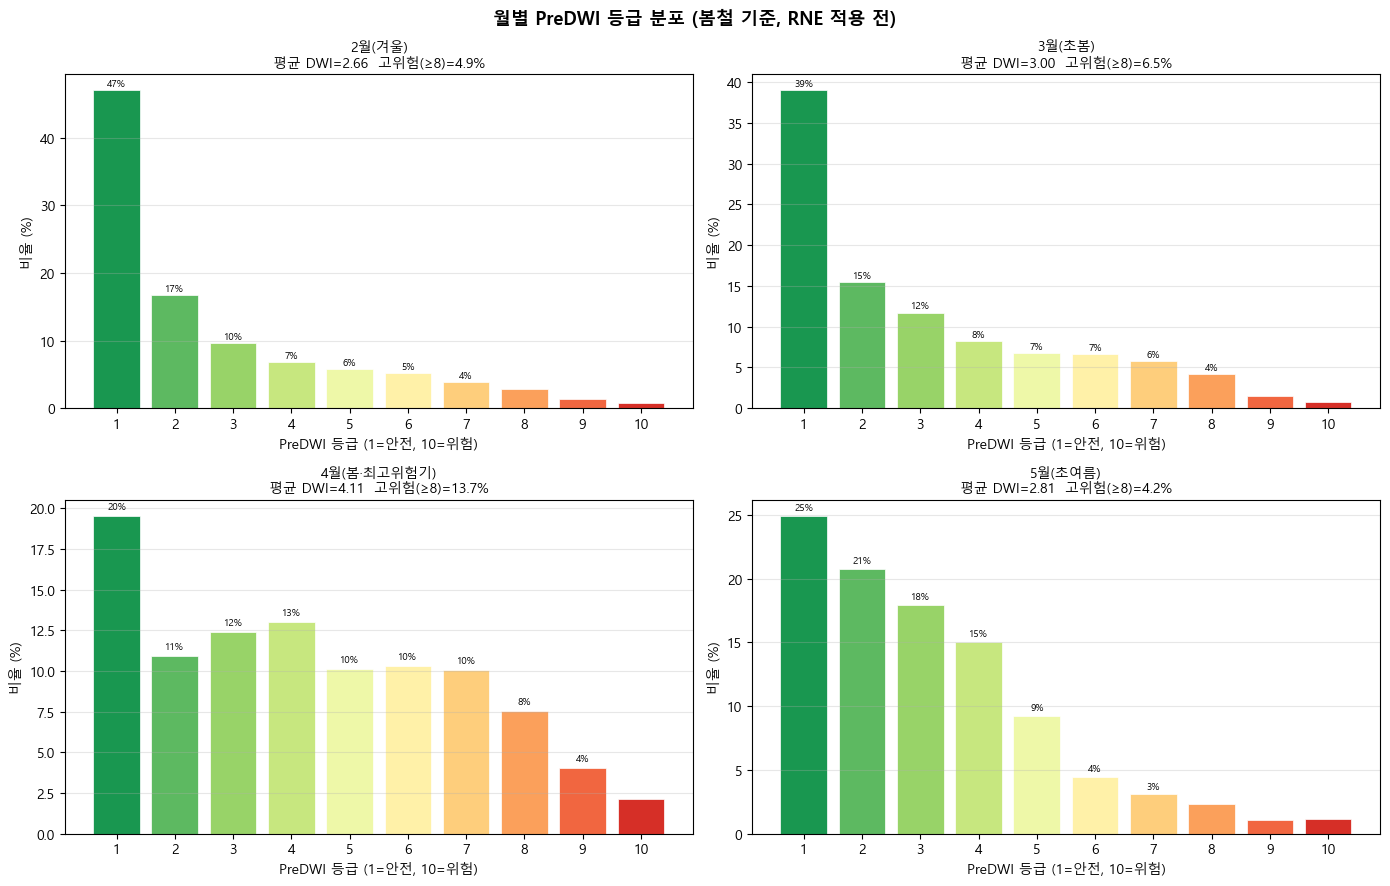

In [4]:
# 월별 DWI 등급 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
month_kr = {'2025-02':'2월(겨울)', '2025-03':'3월(초봄)',
            '2025-04':'4월(봄·최고위험기)', '2025-05':'5월(초여름)'}
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 10))

for ax, m in zip(axes, MONTHS):
    df = pd.read_parquet(DWI_PATH, filters=[('month','==',m)])
    vc = df['predwi_class'].value_counts().sort_index()
    bars = ax.bar(vc.index, vc.values / len(df) * 100,
                  color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{month_kr[m]}\n평균 DWI={df["dwi"].mean():.2f}  고위험(≥8)={( df["dwi"]>=8).mean()*100:.1f}%',
                 fontsize=10)
    ax.set_xlabel('PreDWI 등급 (1=안전, 10=위험)')
    ax.set_ylabel('비율 (%)')
    ax.set_xticks(range(1, 11))
    ax.grid(True, axis='y', alpha=0.3)
    for bar, v in zip(bars, vc.values):
        pct = v/len(df)*100
        if pct > 3:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                    f'{pct:.0f}%', ha='center', va='bottom', fontsize=7)

plt.suptitle('월별 PreDWI 등급 분포 (봄철 기준, RNE 적용 전)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'PREP_05_DWI등급분포.png'), dpi=120, bbox_inches='tight')
plt.show()

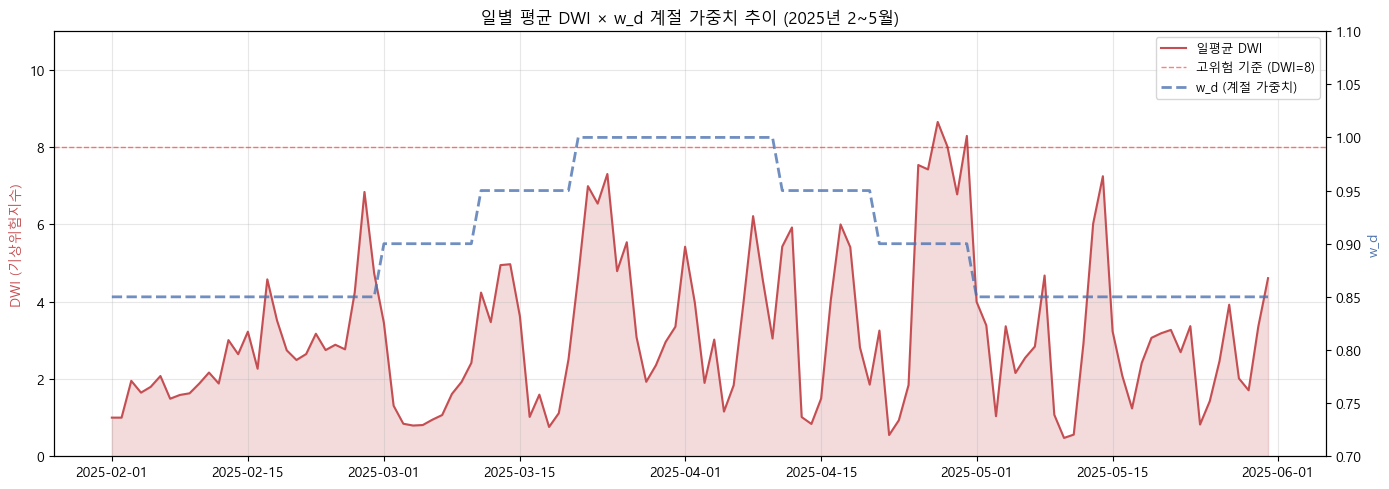

In [5]:
# 일별 평균 DWI 시계열 (전 격자 평균)
daily_dwi = []
for m in MONTHS:
    df = pd.read_parquet(DWI_PATH, filters=[('month','==',m)])
    daily = df.groupby('date')['dwi'].mean().reset_index()
    daily_dwi.append(daily)
daily_dwi = pd.concat(daily_dwi).sort_values('date')

wd_df = pd.read_parquet(WD_PATH)

fig, ax1 = plt.subplots(figsize=(14, 5))

# DWI 시계열
ax1.plot(daily_dwi['date'], daily_dwi['dwi'],
         color='#C44E52', linewidth=1.5, label='일평균 DWI')
ax1.fill_between(daily_dwi['date'], daily_dwi['dwi'],
                  alpha=0.2, color='#C44E52')
ax1.set_ylabel('DWI (기상위험지수)', color='#C44E52')
ax1.set_ylim(0, 11)
ax1.axhline(8, color='red', linewidth=1, linestyle='--', alpha=0.5, label='고위험 기준 (DWI=8)')

# w_d 오버레이
ax2 = ax1.twinx()
ax2.plot(wd_df['date'], wd_df['w_d'],
         color='#4C72B0', linewidth=2, linestyle='--', label='w_d (계절 가중치)', alpha=0.8)
ax2.set_ylabel('w_d', color='#4C72B0')
ax2.set_ylim(0.7, 1.1)

ax1.set_title('일별 평균 DWI × w_d 계절 가중치 추이 (2025년 2~5월)', fontsize=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'PREP_05_DWI시계열.png'), dpi=120, bbox_inches='tight')
plt.show()

---
## 최종 요약

In [6]:
print('=' * 60)
print('  DWI (기상위험지수) 계산 완료')
print('=' * 60)
print('''
  공식 (봄철: 1~6월)
  PreDWI = sigmoid(2.706 + 0.088×기온 - 0.055×습도
                          - 0.023×실효습도 - 0.104×풍속)
  DWI = 재분류등급(1~10) × RNE(0.1~1.0)

  월별 평균 DWI
  - 2월: 2.66  (추운 겨울, PreDWI 낮음 + RNE=1.0)
  - 3월: 3.00  (봄 가뭄 시작)
  - 4월: 4.11  ← 최고  (기온 상승 + 건조 지속)
  - 5월: 2.81  (봄비 효과로 감소)

  고위험(DWI>=8) 격자 비율
  - 4월: 13.7%  ← 산불 최고 위험기와 일치

  저장 위치
  - derived/dwi/ (월별 파티션)
  - 컬럼: grid_id, date, predwi, predwi_class, dwi

  다음 단계
  P-FFDRI = (0.55×DWI + 0.10×FMI + 0.15×TMI + 0.20×PEI) × w_d
  -> FMI(임상), TMI(지형), PEI(전력설비) 파트 추가 필요
''')
print('=' * 60)

  DWI (기상위험지수) 계산 완료

  공식 (봄철: 1~6월)
  PreDWI = sigmoid(2.706 + 0.088×기온 - 0.055×습도
                          - 0.023×실효습도 - 0.104×풍속)
  DWI = 재분류등급(1~10) × RNE(0.1~1.0)

  월별 평균 DWI
  - 2월: 2.66  (추운 겨울, PreDWI 낮음 + RNE=1.0)
  - 3월: 3.00  (봄 가뭄 시작)
  - 4월: 4.11  ← 최고  (기온 상승 + 건조 지속)
  - 5월: 2.81  (봄비 효과로 감소)

  고위험(DWI>=8) 격자 비율
  - 4월: 13.7%  ← 산불 최고 위험기와 일치

  저장 위치
  - derived/dwi/ (월별 파티션)
  - 컬럼: grid_id, date, predwi, predwi_class, dwi

  다음 단계
  P-FFDRI = (0.55×DWI + 0.10×FMI + 0.15×TMI + 0.20×PEI) × w_d
  -> FMI(임상), TMI(지형), PEI(전력설비) 파트 추가 필요

